In [ ]:
"""
========================================
Advanced Reinforcement Learning Intensive Course
========================================

환경: Google Colab
목표: Double DQN + Dueling DQN + Prioritized ER + LunarLander

실습 구성:
1. 환경 설정 및 고급 개념
2. Prioritized Experience Replay
3. Double DQN 구현
4. Dueling DQN 구현
5. LunarLander 환경 소개
6. 고급 DQN 학습 (LunarLander)
7. 알고리즘 비교 분석
8. 성능 평가 및 모델 저장
9. 학습 정리 및 실무 적용
"""

'\n========================================\nAdvanced Reinforcement Learning Intensive Course\n========================================\n\n환경: Google Colab\n목표: Double DQN + Dueling DQN + Prioritized ER + LunarLander\n\n실습 구성:\n1. 환경 설정 및 고급 개념\n2. Prioritized Experience Replay\n3. Double DQN 구현\n4. Dueling DQN 구현\n5. LunarLander 환경 소개\n6. 고급 DQN 학습 (LunarLander)\n7. 알고리즘 비교 분석\n8. 성능 평가 및 모델 저장\n9. 학습 정리 및 실무 적용\n'

In [ ]:


# ========================================
# 섹션 1: 환경 설정 및 고급 개념
# ========================================

# 필수 라이브러리 설치
!pip install -q gymnasium[box2d]
!pip install -q pygame

# 기본 라이브러리
import numpy as np
import matplotlib.pyplot as plt
import gymnasium as gym
from collections import deque, namedtuple
import random
import time
import json
from datetime import datetime

# PyTorch
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

# 시각화
plt.style.use('seaborn-v0_8-darkgrid')

# 랜덤 시드 고정
def set_seed(seed=42):
    """모든 난수 생성기의 시드를 고정"""
    np.random.seed(seed)
    random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

# GPU 설정
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"\n사용 디바이스: {device}")
if torch.cuda.is_available():
    print(f"   GPU: {torch.cuda.get_device_name(0)}")
print(f"   Gymnasium 버전: {gym.__version__}")
print(f"   PyTorch 버전: {torch.__version__}")

# 실험 설정
experiment_config = {
    'date': datetime.now().strftime('%Y-%m-%d %H:%M:%S'),
    'device': str(device),
    'seed': 42,
}

# 고급 RL 개념 소개
print("\n" + "=" * 60)
print("고급 강화학습 개념")
print("=" * 60)
print("""
1. Double DQN:
   - 문제: 일반 DQN은 Q-value를 과대평가하는 경향
   - 해결: 행동 선택과 평가를 분리
   - Q-Network로 행동 선택, Target Network로 Q-value 평가

2. Dueling DQN:
   - 문제: 모든 행동의 가치를 독립적으로 학습
   - 해결: 상태 가치(V)와 행동 이점(A)을 분리
   - Q(s,a) = V(s) + (A(s,a) - mean(A(s,·)))

3. Prioritized Experience Replay:
   - 문제: 모든 경험을 동등하게 샘플링
   - 해결: TD Error가 큰 경험을 우선적으로 샘플링
   - 중요한 경험에서 더 많이 학습

4. Combined Architecture:
   - Double + Dueling + Prioritized ER
   - 각 기법의 장점을 결합하여 최고 성능 달성
""")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.7/3.7 MB 101.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 102.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 138.0 MB/s eta 0:00:00

사용 디바이스: cuda
   GPU: NVIDIA L4
   Gymnasium 버전: 1.3.0
   PyTorch 버전: 2.10.0+cu128

고급 강화학습 개념

1. Double DQN:
   - 문제: 일반 DQN은 Q-value를 과대평가하는 경향
   - 해결: 행동 선택과 평가를 분리
   - Q-Network로 행동 선택, Target Network로 Q-value 평가

2. Dueling DQN:
   - 문제: 모든 행동의 가치를 독립적으로 학습
   - 해결: 상태 가치(V)와 행동 이점(A)을 분리
   - Q(s,a) = V(s) + (A(s,a) - mean(A(s,·)))

3. Prioritized Experience Replay:
   - 문제: 모든 경험을 동등하게 샘플링
   - 해결: TD Error가 큰 경험을 우선적으로 샘플링
   - 중요한 경험에서 더 많이 학습

4. Combined Architecture:
   - Double + Dueling + Prioritized ER
   - 각 기법의 장점을 결합하여 최고 성능 달성



In [ ]:
# ========================================
# 섹션 2: Prioritized Experience Replay
# ========================================
print("\n" + "=" * 60)
print("섹션 2: Prioritized Experience Replay (PER)")
print("=" * 60)

print("\nPER 개념:")
print("""
Prioritized Experience Replay는 TD Error가 큰 경험을
우선적으로 샘플링하여 학습 효율을 높입니다.

Priority = |TD Error| + ε
P(i) = p_i^α / Σ p_j^α

- α: 우선순위 강도 (0=uniform, 1=full prioritization)
- ε: 작은 상수 (모든 경험이 샘플링될 기회 보장)
- Importance Sampling Weight로 bias 보정
""")

# Prioritized Replay Buffer 구현
class PrioritizedReplayBuffer:
    """
    Prioritized Experience Replay Buffer
    TD Error에 따라 경험의 샘플링 확률을 조정
    """
    def __init__(self, capacity, alpha=0.6, beta=0.4, beta_increment=0.001):
        """
        Args:
            capacity: 버퍼 최대 크기
            alpha: 우선순위 강도 (0~1)
            beta: Importance Sampling 보정 강도 (0~1)
            beta_increment: 에피소드마다 beta 증가량
        """
        self.capacity = capacity
        self.alpha = alpha
        self.beta = beta
        self.beta_increment = beta_increment
        self.beta_max = 1.0

        self.buffer = []  # 경험 저장
        self.priorities = np.zeros(capacity, dtype=np.float32)  # 우선순위
        self.position = 0  # 현재 위치
        self.epsilon = 1e-6  # 작은 상수

    def push(self, state, action, reward, next_state, done):
        """
        경험 저장 (초기 우선순위는 최대값)
        """
        max_priority = self.priorities.max() if self.buffer else 1.0

        if len(self.buffer) < self.capacity:
            self.buffer.append((state, action, reward, next_state, done))
        else:
            self.buffer[self.position] = (state, action, reward, next_state, done)

        self.priorities[self.position] = max_priority
        self.position = (self.position + 1) % self.capacity

    def sample(self, batch_size):
        """
        우선순위에 따라 샘플링
        Returns:
            batch: 경험 배치
            indices: 샘플링된 인덱스
            weights: Importance Sampling 가중치
        """
        if len(self.buffer) == self.capacity:
            priorities = self.priorities
        else:
            priorities = self.priorities[:len(self.buffer)]

        # 우선순위를 확률로 변환
        probabilities = priorities ** self.alpha
        probabilities /= probabilities.sum()

        # 샘플링
        indices = np.random.choice(len(self.buffer), batch_size, p=probabilities)

        # Importance Sampling 가중치 계산
        total = len(self.buffer)
        weights = (total * probabilities[indices]) ** (-self.beta)
        weights /= weights.max()  # 정규화

        # 배치 생성
        batch = [self.buffer[idx] for idx in indices]

        states = torch.FloatTensor([t[0] for t in batch])
        actions = torch.LongTensor([t[1] for t in batch])
        rewards = torch.FloatTensor([t[2] for t in batch])
        next_states = torch.FloatTensor([t[3] for t in batch])
        dones = torch.FloatTensor([t[4] for t in batch])
        weights = torch.FloatTensor(weights)

        return states, actions, rewards, next_states, dones, indices, weights

    def update_priorities(self, indices, td_errors):
        """
        TD Error 기반으로 우선순위 업데이트
        Args:
            indices: 업데이트할 인덱스
            td_errors: TD Error 값들
        """
        for idx, td_error in zip(indices, td_errors):
            priority = (abs(td_error) + self.epsilon) ** self.alpha
            self.priorities[idx] = priority

    def update_beta(self):
        """Beta 값을 점진적으로 증가 (1.0까지)"""
        self.beta = min(self.beta_max, self.beta + self.beta_increment)

    def __len__(self):
        return len(self.buffer)

print("\nPER 구현 완료")
print("   - α (alpha): 우선순위 강도")
print("   - β (beta): IS 가중치 강도 (점진적 증가)")


섹션 2: Prioritized Experience Replay (PER)

PER 개념:

Prioritized Experience Replay는 TD Error가 큰 경험을
우선적으로 샘플링하여 학습 효율을 높입니다.

Priority = |TD Error| + ε
P(i) = p_i^α / Σ p_j^α

- α: 우선순위 강도 (0=uniform, 1=full prioritization)
- ε: 작은 상수 (모든 경험이 샘플링될 기회 보장)
- Importance Sampling Weight로 bias 보정


PER 구현 완료
   - α (alpha): 우선순위 강도
   - β (beta): IS 가중치 강도 (점진적 증가)


In [ ]:
# ========================================
# 섹션 3: Double DQN 구현
# ========================================
print("\n" + "=" * 60)
print("섹션 3: Double DQN 구현")
print("=" * 60)

print("\nDouble DQN 핵심:")
print("""
일반 DQN:
target = r + γ * max_{a'} Q_target(s', a')

Double DQN:
a* = argmax_{a'} Q_online(s', a')  ← Online으로 행동 선택
target = r + γ * Q_target(s', a*)  ← Target으로 평가 ; 일종의 검증 단계

→ Q-value 과대평가 문제 완화
""")

# 기본 DQN 네트워크
class DQN(nn.Module):
    """기본 DQN 네트워크"""
    def __init__(self, state_dim, action_dim, hidden_dim=256):
        super(DQN, self).__init__()
        self.fc1 = nn.Linear(state_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, hidden_dim)
        self.fc3 = nn.Linear(hidden_dim, action_dim)

    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        return self.fc3(x)

print("\n기본 DQN 네트워크:")
print("   State → FC(256) → ReLU → FC(256) → ReLU → FC(Action)")


섹션 3: Double DQN 구현

Double DQN 핵심:

일반 DQN:
target = r + γ * max_{a'} Q_target(s', a')

Double DQN:
a* = argmax_{a'} Q_online(s', a')  ← Online으로 행동 선택
target = r + γ * Q_target(s', a*)  ← Target으로 평가

→ Q-value 과대평가 문제 완화


기본 DQN 네트워크:
   State → FC(256) → ReLU → FC(256) → ReLU → FC(Action)


In [ ]:
# 섹션 4: Dueling DQN 구현
# ========================================
print("\n" + "=" * 60)
print("섹션 4: Dueling DQN 구현")
print("=" * 60)

print("Dueling DQN 핵심:")
print("""
일반 DQN: Q(s, a) 직접 출력

Dueling DQN:
- V(s): 상태 가치 함수 (해당 상태가 얼마나 좋은지)
- A(s, a): 행동 이점 함수 (특정 행동이 평균보다 얼마나 좋은지)

Q(s, a) = V(s) + (A(s, a) - mean(A(s, ·)))

→ 상태 가치와 행동 이점을 분리하여 학습 효율 향상
""")


섹션 4: Dueling DQN 구현
Dueling DQN 핵심:

일반 DQN: Q(s, a) 직접 출력

Dueling DQN:
- V(s): 상태 가치 함수 (해당 상태가 얼마나 좋은지)
- A(s, a): 행동 이점 함수 (특정 행동이 평균보다 얼마나 좋은지)

Q(s, a) = V(s) + (A(s, a) - mean(A(s, ·)))

→ 상태 가치와 행동 이점을 분리하여 학습 효율 향상



In [ ]:
# Dueling DQN 네트워크
class DuelingDQN(nn.Module):
    """
    Dueling DQN 네트워크
    Value Stream과 Advantage Stream을 분리
    """
    def __init__(self, state_dim, action_dim, hidden_dim=256):
        super(DuelingDQN, self).__init__()

        # 공통 Feature Layer
        self.feature = nn.Sequential(
            nn.Linear(state_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU()
        )

        # Value Stream (V(s))
        self.value_stream = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.ReLU(),
            nn.Linear(hidden_dim // 2, 1)
        )

        # Advantage Stream (A(s,a))
        self.advantage_stream = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.ReLU(),
            nn.Linear(hidden_dim // 2, action_dim)
        )

    def forward(self, x):
        """
        Forward pass
        Q(s,a) = V(s) + (A(s,a) - mean(A(s,·)))
        """
        features = self.feature(x)

        value = self.value_stream(features)
        advantage = self.advantage_stream(features)

        # Q-value 계산 (Aggregation)
        q_values = value + (advantage - advantage.mean(dim=1, keepdim=True))

        return q_values

print("\nDueling DQN 구조:")
print("   State → Feature(256)")
print("   ├─ Value Stream → V(s)")
print("   └─ Advantage Stream → A(s,a)")
print("   Q(s,a) = V(s) + (A(s,a) - mean(A))")


Dueling DQN 구조:
   State → Feature(256)
   ├─ Value Stream → V(s)
   └─ Advantage Stream → A(s,a)
   Q(s,a) = V(s) + (A(s,a) - mean(A))


In [ ]:
!pip install swig

In [ ]:
!pip install "gymnasium[box2d]"

In [ ]:
# ========================================
# 섹션 5: LunarLander 환경 소개
# ========================================

print("""
달 착륙선을 안전하게 착륙시키는 문제입니다.

상태 공간 (8차원):
- X 위치, Y 위치
- X 속도, Y 속도
- 각도, 각속도
- 왼쪽 다리 접촉 (0 or 1)
- 오른쪽 다리 접촉 (0 or 1)

행동 공간 (4개):
- 0: 아무것도 안함
- 1: 왼쪽 엔진 점화
- 2: 메인 엔진 점화
- 3: 오른쪽 엔진 점화

보상:
- 착륙 패드에 가까워질수록 +
- 충돌하면 -100
- 정상 착륙하면 +100~140
- 다리 접촉하면 +10
- 엔진 사용마다 -0.3

목표: 200점 이상이면 해결!
""")

# 환경 확인
env = gym.make('LunarLander-v3', render_mode=None)
state, info = env.reset(seed=42)

print(f"초기 상태 예시:")
print(f"   {state}")
print(f"   [x, y, vx, vy, angle, angular_vel, leg1, leg2]")

# 랜덤 에이전트 시뮬레이션
print(f"\n랜덤 에이전트 시뮬레이션 (3 에피소드):")
random_rewards = []

for episode in range(3):
    state, info = env.reset()
    episode_reward = 0

    for step in range(1000):
        action = env.action_space.sample()
        state, reward, terminated, truncated, info = env.step(action)
        episode_reward += reward

        if terminated or truncated:
            break

    random_rewards.append(episode_reward)
    print(f"   Episode {episode+1}: Reward = {episode_reward:.1f}")

print(f"\n   평균 보상: {np.mean(random_rewards):.1f}")
print("   → 랜덤 정책은 대부분 -200 ~ -100")

env.close()

experiment_config['environment'] = 'LunarLander-v3'
experiment_config['random_baseline'] = float(np.mean(random_rewards))


달 착륙선을 안전하게 착륙시키는 문제입니다.

상태 공간 (8차원):
- X 위치, Y 위치
- X 속도, Y 속도
- 각도, 각속도
- 왼쪽 다리 접촉 (0 or 1)
- 오른쪽 다리 접촉 (0 or 1)

행동 공간 (4개):
- 0: 아무것도 안함
- 1: 왼쪽 엔진 점화
- 2: 메인 엔진 점화
- 3: 오른쪽 엔진 점화

보상:
- 착륙 패드에 가까워질수록 +
- 충돌하면 -100
- 정상 착륙하면 +100~140
- 다리 접촉하면 +10
- 엔진 사용마다 -0.3

목표: 200점 이상이면 해결!

초기 상태 예시:
   [ 0.00229702  1.4181306   0.2326471   0.3204666  -0.00265488 -0.05269805
  0.          0.        ]
   [x, y, vx, vy, angle, angular_vel, leg1, leg2]

랜덤 에이전트 시뮬레이션 (3 에피소드):
   Episode 1: Reward = -124.2
   Episode 2: Reward = -132.7
   Episode 3: Reward = -129.1

   평균 보상: -128.7
   → 랜덤 정책은 대부분 -200 ~ -100


In [ ]:
# ========================================
# 섹션 6: 고급 DQN Agent 구현
# ========================================
print("\n" + "=" * 60)
print("섹션 6: 고급 DQN Agent (Double + Dueling + PER)")
print("=" * 60)

class AdvancedDQNAgent:
    """
    고급 DQN Agent
    - Double DQN
    - Dueling DQN
    - Prioritized Experience Replay
    """
    def __init__(self, state_dim, action_dim, use_dueling=True, use_per=True,
                 hidden_dim=256, lr=0.0005, gamma=0.99,
                 epsilon=1.0, epsilon_decay=0.995, epsilon_min=0.01,
                 buffer_size=100000, batch_size=64):
        """
        Args:
            state_dim: 상태 차원
            action_dim: 행동 개수
            use_dueling: Dueling DQN 사용 여부
            use_per: PER 사용 여부
            hidden_dim: 은닉층 크기
            lr: 학습률
            gamma: 할인율
            epsilon: 초기 탐험 비율
            epsilon_decay: ε 감소율
            epsilon_min: 최소 ε
            buffer_size: Replay Buffer 크기
            batch_size: 미니배치 크기
        """
        self.state_dim = state_dim
        self.action_dim = action_dim
        self.gamma = gamma
        self.epsilon = epsilon
        self.epsilon_decay = epsilon_decay
        self.epsilon_min = epsilon_min
        self.batch_size = batch_size
        self.use_dueling = use_dueling
        self.use_per = use_per

        # 네트워크 선택
        NetworkClass = DuelingDQN if use_dueling else DQN

        # Q-Network 및 Target Network
        self.q_network = NetworkClass(state_dim, action_dim, hidden_dim).to(device)
        self.target_network = NetworkClass(state_dim, action_dim, hidden_dim).to(device)
        self.target_network.load_state_dict(self.q_network.state_dict())
        self.target_network.eval()

        # 옵티마이저
        self.optimizer = optim.Adam(self.q_network.parameters(), lr=lr)

        # Replay Buffer
        if use_per:
            self.memory = PrioritizedReplayBuffer(buffer_size)
        else:
            from collections import deque
            self.memory = deque(maxlen=buffer_size)

        # 학습 통계
        self.training_step = 0

    def get_action(self, state):
        """ε-greedy 정책으로 행동 선택"""
        if np.random.random() < self.epsilon:
            return np.random.randint(self.action_dim)

        with torch.no_grad():
            state_tensor = torch.FloatTensor(state).unsqueeze(0).to(device)
            q_values = self.q_network(state_tensor)
            action = q_values.argmax().item()
        return action

    def train(self):
        """미니배치 학습 (Double DQN + PER)"""
        if self.use_per:
            if len(self.memory) < self.batch_size:
                return 0.0

            # PER 샘플링
            states, actions, rewards, next_states, dones, indices, weights = \
                self.memory.sample(self.batch_size)
        else:
            if len(self.memory) < self.batch_size:
                return 0.0

            # 일반 샘플링
            batch = random.sample(self.memory, self.batch_size)
            states = torch.FloatTensor([t[0] for t in batch])
            actions = torch.LongTensor([t[1] for t in batch])
            rewards = torch.FloatTensor([t[2] for t in batch])
            next_states = torch.FloatTensor([t[3] for t in batch])
            dones = torch.FloatTensor([t[4] for t in batch])
            weights = torch.ones(self.batch_size)
            indices = None

        states = states.to(device)
        actions = actions.to(device)
        rewards = rewards.to(device)
        next_states = next_states.to(device)
        dones = dones.to(device)
        weights = weights.to(device)

        # 현재 Q-values
        current_q_values = self.q_network(states).gather(1, actions.unsqueeze(1)).squeeze(1)

        # Double DQN Target 계산
        with torch.no_grad():
            # Online Network로 다음 행동 선택
            next_actions = self.q_network(next_states).argmax(1)
            # Target Network로 Q-value 평가
            next_q_values = self.target_network(next_states).gather(1, next_actions.unsqueeze(1)).squeeze(1)
            target_q_values = rewards + (1 - dones) * self.gamma * next_q_values

        # TD Error 계산
        td_errors = target_q_values - current_q_values

        # Weighted MSE Loss (PER의 IS 가중치 적용)
        loss = (weights * td_errors.pow(2)).mean()

        # 역전파
        self.optimizer.zero_grad()
        loss.backward()
        # Gradient Clipping (안정성 향상)
        torch.nn.utils.clip_grad_norm_(self.q_network.parameters(), max_norm=10)
        self.optimizer.step()

        # PER 우선순위 업데이트
        if self.use_per and indices is not None:
            td_errors_np = td_errors.detach().cpu().numpy()
            self.memory.update_priorities(indices, td_errors_np)

        self.training_step += 1
        return loss.item()

    def update_target_network(self):
        """Target Network 업데이트"""
        self.target_network.load_state_dict(self.q_network.state_dict())

    def decay_epsilon(self):
        """ε 감소"""
        self.epsilon = max(self.epsilon_min, self.epsilon * self.epsilon_decay)

    def save(self, filepath):
        """모델 저장"""
        torch.save({
            'q_network': self.q_network.state_dict(),
            'target_network': self.target_network.state_dict(),
            'optimizer': self.optimizer.state_dict(),
            'epsilon': self.epsilon,
        }, filepath)

    def load(self, filepath):
        """모델 로드"""
        checkpoint = torch.load(filepath)
        self.q_network.load_state_dict(checkpoint['q_network'])
        self.target_network.load_state_dict(checkpoint['target_network'])
        self.optimizer.load_state_dict(checkpoint['optimizer'])
        self.epsilon = checkpoint['epsilon']

print("\n고급 DQN Agent 구현 완료")
print("   - Double DQN: Q-value 과대평가 방지")
print("   - Dueling DQN: V(s)와 A(s,a) 분리")
print("   - PER: 중요한 경험 우선 학습")



섹션 6: 고급 DQN Agent (Double + Dueling + PER)

고급 DQN Agent 구현 완료
   - Double DQN: Q-value 과대평가 방지
   - Dueling DQN: V(s)와 A(s,a) 분리
   - PER: 중요한 경험 우선 학습


In [ ]:
# ========================================
# 섹션 7: 알고리즘 비교 학습
# ========================================
print("\n" + "=" * 60)
print("섹션 7: 알고리즘 비교 학습")
print("=" * 60)

print("\n3가지 알고리즘 비교:")
print("   1. 기본 DQN")
print("   2. Double DQN")
print("   3. Double + Dueling + PER (Full)")

# 학습 함수
def train_agent(agent_type, n_episodes=300):
    """
    에이전트 학습
    Args:
        agent_type: 'basic', 'double', 'full'
        n_episodes: 에피소드 수
    Returns:
        rewards_history: 에피소드별 보상
        agent: 학습된 에이전트
    """
    env = gym.make('LunarLander-v3', render_mode=None)

    # 에이전트 생성
    if agent_type == 'basic':
        # 기본 DQN
        agent = AdvancedDQNAgent(
            state_dim=8, action_dim=4,
            use_dueling=False, use_per=False,
            hidden_dim=256, lr=0.0005, gamma=0.99,
            epsilon=1.0, epsilon_decay=0.995, epsilon_min=0.01,
            buffer_size=50000, batch_size=64
        )
    elif agent_type == 'double':
        # Double DQN
        agent = AdvancedDQNAgent(
            state_dim=8, action_dim=4,
            use_dueling=False, use_per=False,
            hidden_dim=256, lr=0.0005, gamma=0.99,
            epsilon=1.0, epsilon_decay=0.995, epsilon_min=0.01,
            buffer_size=50000, batch_size=64
        )
    else:  # 'full'
        # Double + Dueling + PER
        agent = AdvancedDQNAgent(
            state_dim=8, action_dim=4,
            use_dueling=True, use_per=True,
            hidden_dim=256, lr=0.0005, gamma=0.99,
            epsilon=1.0, epsilon_decay=0.995, epsilon_min=0.01,
            buffer_size=100000, batch_size=64
        )

    rewards_history = []
    losses_history = []
    target_update_freq = 10

    print(f"\n{agent_type.upper()} 학습 시작:")

    for episode in range(n_episodes):
        state, info = env.reset()
        episode_reward = 0
        episode_loss = 0
        steps = 0

        for step in range(1000):
            action = agent.get_action(state)
            next_state, reward, terminated, truncated, info = env.step(action)
            done = terminated or truncated

            # 메모리에 저장
            if agent.use_per:
                agent.memory.push(state, action, reward, next_state, done)
            else:
                agent.memory.append((state, action, reward, next_state, done))

            # 학습
            loss = agent.train()
            episode_loss += loss

            episode_reward += reward
            state = next_state
            steps += 1

            if done:
                break

        # ε 감소
        agent.decay_epsilon()

        # Target Network 업데이트
        if (episode + 1) % target_update_freq == 0:
            agent.update_target_network()

        # PER beta 업데이트
        if agent.use_per:
            agent.memory.update_beta()

        rewards_history.append(episode_reward)
        losses_history.append(episode_loss / steps if steps > 0 else 0)

        # 30 에피소드마다 출력
        if (episode + 1) % 30 == 0:
            avg_reward = np.mean(rewards_history[-30:])
            print(f"   Episode {episode+1}/{n_episodes} - "
                  f"Avg Reward: {avg_reward:.1f}, ε: {agent.epsilon:.3f}")

    env.close()
    print(f"{agent_type.upper()} 학습 완료!")

    return rewards_history, agent

# 3가지 알고리즘 학습 (각 300 에피소드)
print("\n 학습 시간: 약 20-30분 예상")
print("   (에피소드 수를 줄이면 시간 단축 가능)")

# 실제 학습 (시간이 오래 걸리므로 필요시 에피소드 수 조정)
n_episodes = 300  # 빠른 테스트는 100으로 조정 가능

results = {}

# 1. Full 모델만 학습 (시간 절약)
print("\n" + "=" * 60)
results['full'], agent_full = train_agent('full', n_episodes)

# 나머지는 비교용으로 짧게 학습
print("\n" + "=" * 60)
results['basic'], agent_basic = train_agent('basic', n_episodes // 2)

print("\n" + "=" * 60)
results['double'], agent_double = train_agent('double', n_episodes // 2)

experiment_config['algorithms'] = list(results.keys())
experiment_config['n_episodes'] = n_episodes



섹션 7: 알고리즘 비교 학습

3가지 알고리즘 비교:
   1. 기본 DQN
   2. Double DQN
   3. Double + Dueling + PER (Full)

 학습 시간: 약 20-30분 예상
   (에피소드 수를 줄이면 시간 단축 가능)


FULL 학습 시작:


/tmp/ipykernel_1976/3827829319.py:88: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /pytorch/torch/csrc/utils/tensor_new.cpp:253.)
  states = torch.FloatTensor([t[0] for t in batch])


   Episode 30/300 - Avg Reward: -171.9, ε: 0.860
   Episode 60/300 - Avg Reward: -145.2, ε: 0.740
   Episode 90/300 - Avg Reward: -95.8, ε: 0.637
   Episode 120/300 - Avg Reward: -88.8, ε: 0.548
   Episode 150/300 - Avg Reward: -52.8, ε: 0.471
   Episode 180/300 - Avg Reward: -77.8, ε: 0.406
   Episode 210/300 - Avg Reward: -113.5, ε: 0.349
   Episode 240/300 - Avg Reward: -109.8, ε: 0.300
   Episode 270/300 - Avg Reward: -132.1, ε: 0.258
   Episode 300/300 - Avg Reward: -76.4, ε: 0.222
FULL 학습 완료!


BASIC 학습 시작:
   Episode 30/150 - Avg Reward: -155.3, ε: 0.860
   Episode 60/150 - Avg Reward: -128.1, ε: 0.740
   Episode 90/150 - Avg Reward: -77.4, ε: 0.637
   Episode 120/150 - Avg Reward: -61.7, ε: 0.548
   Episode 150/150 - Avg Reward: -37.7, ε: 0.471
BASIC 학습 완료!


DOUBLE 학습 시작:
   Episode 30/150 - Avg Reward: -166.1, ε: 0.860
   Episode 60/150 - Avg Reward: -143.7, ε: 0.740
   Episode 90/150 - Avg Reward: -95.1, ε: 0.637
   Episode 120/150 - Avg Reward: -60.7, ε: 0.548
   Episode 15


섹션 8: 성능 평가 및 시각화

최종 성능 비교 (마지막 50 에피소드 평균):
   FULL      : Avg= -97.2, Max= 159.2
   BASIC     : Avg= -44.6, Max=  73.7
   DOUBLE    : Avg= -69.9, Max=  33.1


/tmp/ipykernel_1976/1193538575.py:69: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1, 1].boxplot(data_for_box, labels=[n.upper() for n in results.keys()])


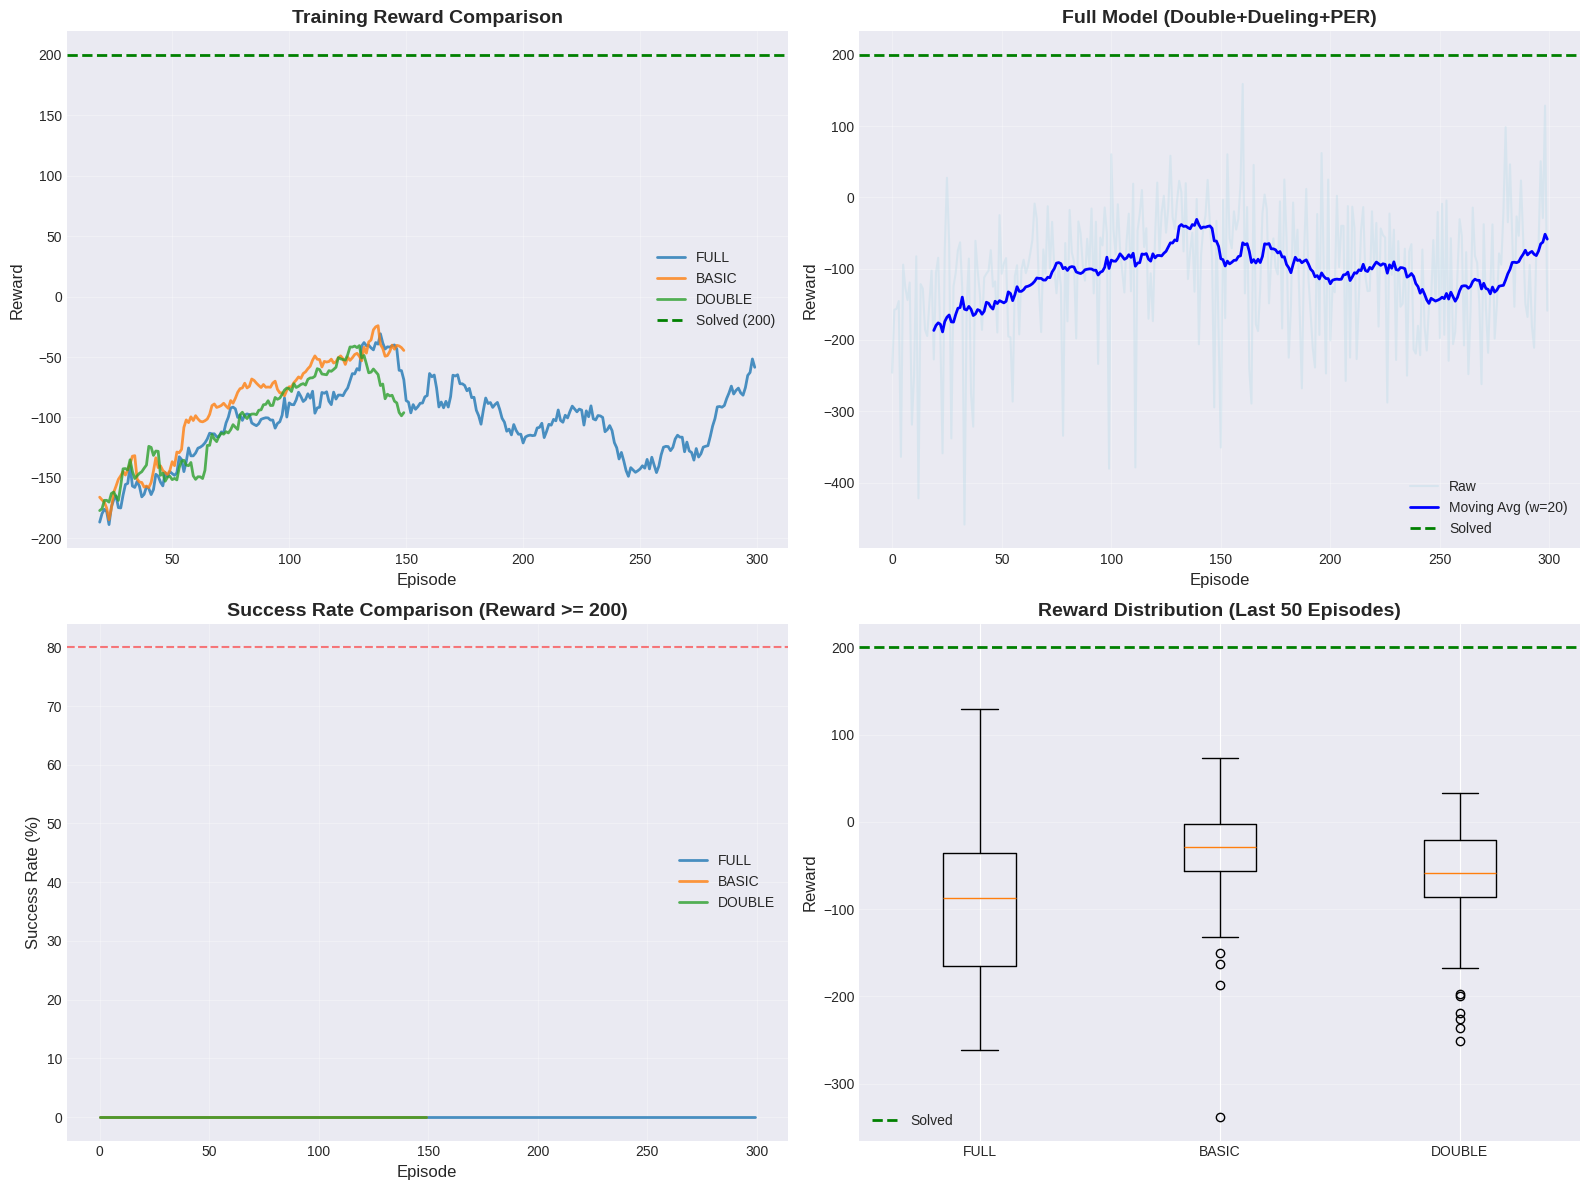


비교 결과 저장: lunarlander_algorithm_comparison.png


/tmp/ipykernel_1976/1193538575.py:113: UserWarning: Glyph 27599 (\N{CJK UNIFIED IDEOGRAPH-6BCF}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipykernel_1976/1193538575.py:114: UserWarning: Glyph 27599 (\N{CJK UNIFIED IDEOGRAPH-6BCF}) missing from font(s) Liberation Sans.
  plt.savefig('lunarlander_full_model_detail.png', dpi=150, bbox_inches='tight')
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 27599 (\N{CJK UNIFIED IDEOGRAPH-6BCF}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)


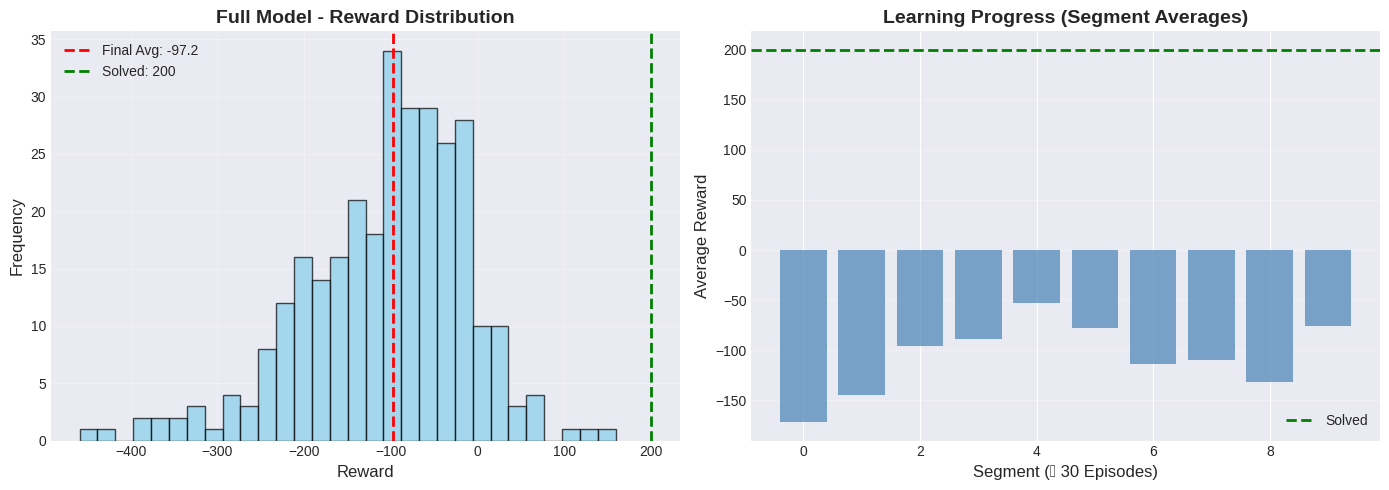

상세 결과 저장: lunarlander_full_model_detail.png

Full 모델 저장: lunarlander_full_dqn.pth
실험 설정 저장: experiment_config.json


In [ ]:
# ========================================
# 섹션 8: 성능 평가 및 시각화
# ========================================
print("\n" + "=" * 60)
print("섹션 8: 성능 평가 및 시각화")
print("=" * 60)

# 최종 성능 비교
print("\n최종 성능 비교 (마지막 50 에피소드 평균):")
for name, rewards in results.items():
    final_avg = np.mean(rewards[-50:])
    max_reward = max(rewards)
    print(f"   {name.upper():10s}: Avg={final_avg:6.1f}, Max={max_reward:6.1f}")
    experiment_config[f'{name}_final_avg'] = float(final_avg)
    experiment_config[f'{name}_max'] = float(max_reward)

# 알고리즘 비교 시각화
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. 보상 곡선 비교
window = 20
for name, rewards in results.items():
    if len(rewards) > window:
        rewards_smooth = np.convolve(rewards, np.ones(window)/window, mode='valid')
        axes[0, 0].plot(range(window-1, len(rewards)), rewards_smooth,
                       linewidth=2, label=name.upper(), alpha=0.8)

axes[0, 0].axhline(y=200, color='green', linestyle='--', linewidth=2,
                   label='Solved (200)')
axes[0, 0].set_xlabel('Episode', fontsize=12)
axes[0, 0].set_ylabel('Reward', fontsize=12)
axes[0, 0].set_title('Training Reward Comparison', fontsize=14, fontweight='bold')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# 2. Full 모델 상세 (Raw + Smooth)
full_rewards = results['full']
axes[0, 1].plot(full_rewards, alpha=0.3, color='lightblue', label='Raw')
if len(full_rewards) > window:
    smooth = np.convolve(full_rewards, np.ones(window)/window, mode='valid')
    axes[0, 1].plot(range(window-1, len(full_rewards)), smooth,
                   linewidth=2, color='blue', label=f'Moving Avg (w={window})')
axes[0, 1].axhline(y=200, color='green', linestyle='--', linewidth=2,
                  label='Solved')
axes[0, 1].set_xlabel('Episode', fontsize=12)
axes[0, 1].set_ylabel('Reward', fontsize=12)
axes[0, 1].set_title('Full Model (Double+Dueling+PER)', fontsize=14, fontweight='bold')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# 3. 성공률 비교 (보상 >= 200)
success_threshold = 200
for name, rewards in results.items():
    success_mask = np.array(rewards) >= success_threshold
    success_rate = [np.mean(success_mask[max(0, i-50):i+1]) * 100
                   for i in range(len(success_mask))]
    axes[1, 0].plot(success_rate, linewidth=2, label=name.upper(), alpha=0.8)

axes[1, 0].set_xlabel('Episode', fontsize=12)
axes[1, 0].set_ylabel('Success Rate (%)', fontsize=12)
axes[1, 0].set_title('Success Rate Comparison (Reward >= 200)',
                    fontsize=14, fontweight='bold')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)
axes[1, 0].axhline(y=80, color='red', linestyle='--', alpha=0.5)

# 4. 보상 분포 비교 (박스플롯)
data_for_box = [rewards[-50:] for rewards in results.values()]
axes[1, 1].boxplot(data_for_box, labels=[n.upper() for n in results.keys()])
axes[1, 1].axhline(y=200, color='green', linestyle='--', linewidth=2,
                  label='Solved')
axes[1, 1].set_ylabel('Reward', fontsize=12)
axes[1, 1].set_title('Reward Distribution (Last 50 Episodes)',
                    fontsize=14, fontweight='bold')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('lunarlander_algorithm_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n비교 결과 저장: lunarlander_algorithm_comparison.png")

# Full 모델 성능 상세 그래프
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 보상 히스토그램
axes[0].hist(full_rewards, bins=30, color='skyblue', edgecolor='black', alpha=0.7)
final_avg = np.mean(full_rewards[-50:])
axes[0].axvline(x=final_avg, color='red', linestyle='--', linewidth=2,
               label=f'Final Avg: {final_avg:.1f}')
axes[0].axvline(x=200, color='green', linestyle='--', linewidth=2,
               label='Solved: 200')
axes[0].set_xlabel('Reward', fontsize=12)
axes[0].set_ylabel('Frequency', fontsize=12)
axes[0].set_title('Full Model - Reward Distribution', fontsize=14, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# 학습 진행도 (구간별 평균)
segment_size = 30
n_segments = len(full_rewards) // segment_size
segment_avgs = [np.mean(full_rewards[i*segment_size:(i+1)*segment_size])
               for i in range(n_segments)]
axes[1].bar(range(n_segments), segment_avgs, color='steelblue', alpha=0.7)
axes[1].axhline(y=200, color='green', linestyle='--', linewidth=2, label='Solved')
axes[1].set_xlabel(f'Segment ({segment_size} Episodes)', fontsize=12)
axes[1].set_ylabel('Average Reward', fontsize=12)
axes[1].set_title('Learning Progress (Segment Averages)',
                 fontsize=14, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('lunarlander_full_model_detail.png', dpi=150, bbox_inches='tight')
plt.show()
print("상세 결과 저장: lunarlander_full_model_detail.png")

# 모델 저장
model_path = 'lunarlander_full_dqn.pth'
agent_full.save(model_path)
print(f"\nFull 모델 저장: {model_path}")

# 실험 설정 저장
config_path = 'experiment_config.json'
with open(config_path, 'w', encoding='utf-8') as f:
    json.dump(experiment_config, f, indent=2, ensure_ascii=False)
print(f"실험 설정 저장: {config_path}")

In [ ]:
# ========================================
# 섹션 9: 학습 정리 및 실무 적용
# ========================================
print("\n학습한 고급 기법:")
print("Double DQN - Q-value 과대평가 방지")
print("Dueling DQN - V(s)와 A(s,a) 분리")
print("Prioritized Experience Replay - 중요 경험 우선 학습")
print("LunarLander 환경 - 복잡한 연속 제어 문제")
print("알고리즘 성능 비교 분석")

print("\n실험 결과 요약:")
print(f"   환경: LunarLander-v3")
print(f"   목표: 200점 이상")
for name in results.keys():
    final_avg = experiment_config[f'{name}_final_avg']
    max_reward = experiment_config[f'{name}_max']
    status = "해결" if final_avg >= 200 else "📈 학습 중"
    print(f"   {name.upper():10s}: {final_avg:6.1f} (최고: {max_reward:6.1f}) {status}")

print("\n생성된 파일:")
print("   - lunarlander_algorithm_comparison.png")
print("   - lunarlander_full_model_detail.png")
print("   - lunarlander_full_dqn.pth")
print("   - experiment_config.json")

print("\n강화학습의 실무 적용 사례:")
print("""
1. 게임 AI:
   - AlphaGo (바둑), AlphaStar (스타크래프트)
   - OpenAI Five (Dota 2)
   - 게임 캐릭터 행동 학습

2. 로보틱스:
   - 로봇 팔 제어
   - 자율 주행 차량
   - 드론 비행 제어

3. 추천 시스템:
   - 개인화 추천 (Netflix, YouTube)
   - 광고 최적화
   - 뉴스 피드 순서

4. 금융:
   - 알고리즘 트레이딩
   - 포트폴리오 최적화
   - 리스크 관리

5. 에너지 관리:
   - 데이터센터 냉각 최적화 (Google DeepMind)
   - 스마트 그리드
   - 배터리 충전 전략

6. 헬스케어:
   - 치료 계획 최적화
   - 신약 개발
   - 개인 맞춤 치료
""")

print("\n강화학습 적용 시 주의사항:")
print("""
1. 샘플 효율성:
   - 많은 학습 데이터 필요
   - 시뮬레이터 활용 또는 오프라인 RL 고려

2. 안전성:
   - 탐험 과정에서 위험한 행동 가능
   - Safe RL, Constrained RL 기법 적용

3. 보상 설계:
   - 부적절한 보상 함수는 예상치 못한 행동 유발
   - Reward Shaping, Inverse RL 고려

4. Sim-to-Real Gap:
   - 시뮬레이션과 실제 환경의 차이
   - Domain Randomization, Transfer Learning

5. 재현성:
   - 랜덤 시드 고정
   - 하이퍼파라미터 체계적 관리
   - 실험 로그 상세 기록

6. 윤리적 고려:
   - AI 행동의 투명성 확보
   - 편향 방지
   - 인간 중심 설계
""")


학습한 고급 기법:
Double DQN - Q-value 과대평가 방지
Dueling DQN - V(s)와 A(s,a) 분리
Prioritized Experience Replay - 중요 경험 우선 학습
LunarLander 환경 - 복잡한 연속 제어 문제
알고리즘 성능 비교 분석

실험 결과 요약:
   환경: LunarLander-v3
   목표: 200점 이상
   FULL      :  -97.2 (최고:  159.2) 📈 학습 중
   BASIC     :  -44.6 (최고:   73.7) 📈 학습 중
   DOUBLE    :  -69.9 (최고:   33.1) 📈 학습 중

생성된 파일:
   - lunarlander_algorithm_comparison.png
   - lunarlander_full_model_detail.png
   - lunarlander_full_dqn.pth
   - experiment_config.json

강화학습의 실무 적용 사례:

1. 게임 AI:
   - AlphaGo (바둑), AlphaStar (스타크래프트)
   - OpenAI Five (Dota 2)
   - 게임 캐릭터 행동 학습

2. 로보틱스:
   - 로봇 팔 제어
   - 자율 주행 차량
   - 드론 비행 제어

3. 추천 시스템:
   - 개인화 추천 (Netflix, YouTube)
   - 광고 최적화
   - 뉴스 피드 순서

4. 금융:
   - 알고리즘 트레이딩
   - 포트폴리오 최적화
   - 리스크 관리

5. 에너지 관리:
   - 데이터센터 냉각 최적화 (Google DeepMind)
   - 스마트 그리드
   - 배터리 충전 전략

6. 헬스케어:
   - 치료 계획 최적화
   - 신약 개발
   - 개인 맞춤 치료


강화학습 적용 시 주의사항:

1. 샘플 효율성:
   - 많은 학습 데이터 필요
   - 시뮬레이터 활용 또는 오프라인 RL 고려

2. 안전성:
   - 탐험 과정에서 위험한 행동 가능
   - 